# Rae2822 2D Wing Slice Model

### Import Library

In [41]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns

### Loading Data

In [42]:
angles = range(21)

folder_path = "./data/rae2822/angvar_sa/"

files = sorted(glob.glob(f"{folder_path}*/surface_flow.csv"))

master_df = []

for i, filename in enumerate(files):
    df = pd.read_csv(filename)

    # apply angles for each case
    df['AoA'] = angles[i]

    master_df.append(df)

# Combine into one training set
full_data = pd.concat(master_df, ignore_index=True)

In [43]:
print(f"Total rows: {len(full_data)}")
full_data.head()

Total rows: 4032


,PointID,x,y,Density,Momentum_x,Momentum_y,Energy,Nu_Tilde,Pressure,Temperature,Mach,Pressure_Coefficient,Laminar_Viscosity,Skin_Friction_Coefficient_x,Skin_Friction_Coefficient_y,Heat_Flux,Y_Plus,Eddy_Viscosity,AoA
0,25,0.985397,0.000943,0.467747,0.0,0.0,106411.802258,0.0,42564.720903,317.006918,0.0,0.262408,0.000019,0.002042,-8.852195e-05,-175.102208,2.161991,0.0,0
1,51,0.969573,0.001489,0.470406,0.0,0.0,107034.099699,0.0,42813.639880,317.058955,0.0,0.279663,0.000019,0.001661,-3.739569e-05,-75.599800,1.954830,0.0,0
2,77,0.952680,0.001679,0.472434,0.0,0.0,107515.203056,0.0,43006.081222,317.116347,0.0,0.293002,0.000019,0.001458,-9.411266e-07,-43.903973,1.834732,0.0,0
3,103,0.934996,0.001511,0.472826,0.0,0.0,107615.419162,0.0,43046.167665,317.149233,0.0,0.295781,0.000019,0.001345,2.838548e-05,-31.992952,1.763323,0.0,0
4,129,0.916822,0.000923,0.472299,0.0,0.0,107499.088533,0.0,42999.635413,317.159465,0.0,0.292556,0.000019,0.001284,5.265905e-05,-27.650354,1.722190,0.0,0


### Model

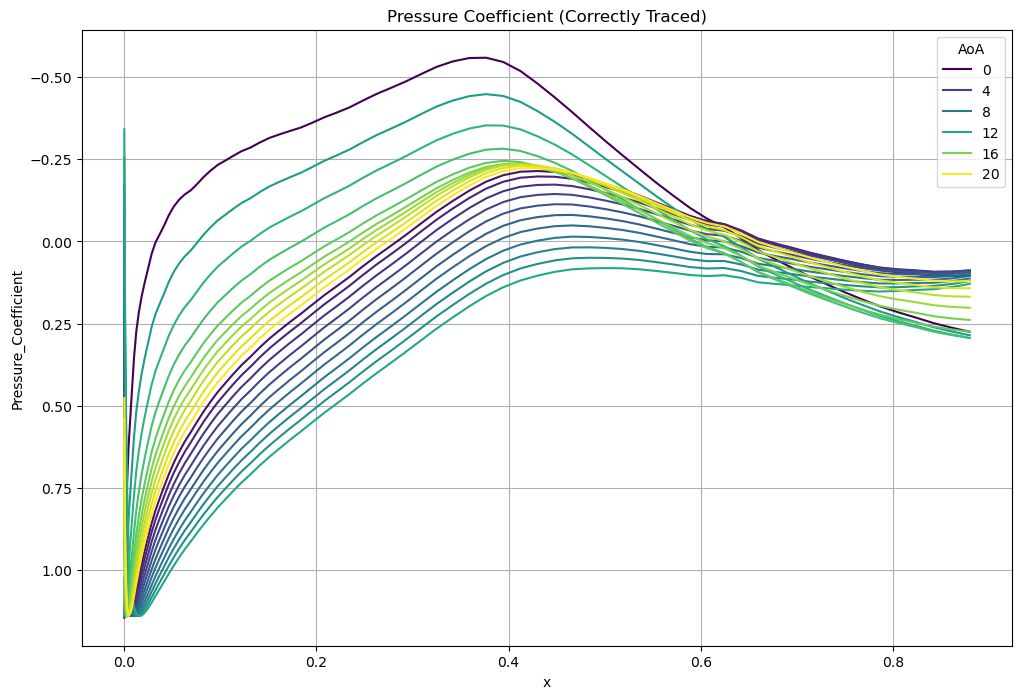

In [59]:
plt.figure(figsize=(12, 8))

upper_surf = full_data[full_data['y'] >= 0]
lower_surf = full_data[full_data['y'] < 0]

sns.lineplot(
    data=lower_surf, 
    x='x', 
    y='Pressure_Coefficient', 
    hue='AoA', 
    palette='viridis', 
    legend="brief",
    sort=False  # <--- THIS IS THE KEY FIX
)

plt.gca().invert_yaxis()
plt.title('Pressure Coefficient (Correctly Traced)')
plt.grid(True)
plt.show()